IMPORT PRICES

In [1]:
import os
from dotenv import load_dotenv

load_dotenv()

api_key = os.getenv("ENTSOE_API_KEY")
print("clé =", api_key[:5], "...")


clé = d1f8b ...


In [2]:
from pathlib import Path
import os
import pandas as pd

from dotenv import load_dotenv

PROJECT_ROOT = Path.cwd()  # if notebook is in project root, otherwise adjust
DATA_DIR = PROJECT_ROOT / "data"
DATA_DIR.mkdir(exist_ok=True)

# Clé API (depuis .env)
load_dotenv(PROJECT_ROOT / ".env")
API_KEY = os.getenv("ENTSOE_API_KEY")
if not API_KEY:
    raise RuntimeError("ENTSOE_API_KEY manquante. Vérifie carma-research/.env")


In [3]:
from entsoe import EntsoePandasClient

import openmeteo_requests
import requests_cache
from retry_requests import retry


In [4]:
import pandas as pd
from entsoe import EntsoePandasClient

client = EntsoePandasClient(api_key=API_KEY)

ZONE = "DE_LU"

start = pd.Timestamp("2023-01-01", tz="UTC")
end_exclusive = pd.Timestamp("2025-12-31", tz="UTC")  

prices = client.query_day_ahead_prices(ZONE, start=start, end=end_exclusive)

prices_df = prices.to_frame(name="price_eur_mwh")
prices_df.index.name = "datetime"

prices_path = DATA_DIR / "prices.csv"
prices_df.to_csv(prices_path)
prices_df.head()  


,price_eur_mwh
datetime,
2023-01-01 01:00:00+01:00,-1.07
2023-01-01 02:00:00+01:00,-1.47
2023-01-01 03:00:00+01:00,-5.08
2023-01-01 04:00:00+01:00,-4.49
2023-01-01 05:00:00+01:00,-5.40


In [5]:
prices_df = prices.to_frame(name="price_eur_mwh")
prices_df.index.name = "datetime"

#convert in UTC timezone
prices_df.index = prices_df.index.tz_convert("UTC")

# sauvegarde
prices_path = DATA_DIR / "prices.csv"
prices_df.to_csv(prices_path)

prices_df.head()


,price_eur_mwh
datetime,
2023-01-01 00:00:00+00:00,-1.07
2023-01-01 01:00:00+00:00,-1.47
2023-01-01 02:00:00+00:00,-5.08
2023-01-01 03:00:00+00:00,-4.49
2023-01-01 04:00:00+00:00,-5.40


IMPORT METEO

In [6]:
import pandas as pd
import openmeteo_requests
import requests_cache
from retry_requests import retry

cache_session = requests_cache.CachedSession(".cache", expire_after=3600)
retry_session = retry(cache_session, retries=5, backoff_factor=0.2)
openmeteo = openmeteo_requests.Client(session=retry_session)

latitude = 52.52 #for Berlin
longitude = 13.41

url = "https://archive-api.open-meteo.com/v1/archive"  # historique :contentReference[oaicite:1]{index=1}

params = {
    "latitude": latitude,
    "longitude": longitude,
    "hourly": ["temperature_2m"],
    "timezone": "UTC",                 
    "start_date": "2020-01-01",
    "end_date": "2025-12-30",          
}

responses = openmeteo.weather_api(url, params=params)
response = responses[0]

hourly = response.Hourly()
temperature_2m = hourly.Variables(0).ValuesAsNumpy()

time_index = pd.date_range(
    start=pd.to_datetime(hourly.Time(), unit="s", utc=True),
    end=pd.to_datetime(hourly.TimeEnd(), unit="s", utc=True),
    freq=pd.Timedelta(seconds=hourly.Interval()),
    inclusive="left",
)

temp_df = pd.DataFrame({"temperature_c": temperature_2m}, index=time_index) #pandas series with datetime index
temp_df.index.name = "datetime"

"""# Sauvegarde brute
temp_path = DATA_DIR / "temperature.csv"
temp_df.to_csv(temp_path)
temp_df.head()"""



'# Sauvegarde brute\ntemp_path = DATA_DIR / "temperature.csv"\ntemp_df.to_csv(temp_path)\ntemp_df.head()'

In [7]:
temp_path = DATA_DIR / "temperature.csv" #cree emplacement
temp_df.to_csv(temp_path) #écrit dans le fichier
temp_path #affiche chmein fichier


WindowsPath('c:/Users/gabri/Documents/quant-projects/carma-research/data/temperature.csv')

DESEASONALISE TEMPERATURE

In [16]:
import numpy as np

P_day = 24
P_year = 365.25 * 24
K_day = 3
K_year = 3

temp = temp_df["temperature_c"].sort_index().asfreq("h").interpolate(method="linear") #temp_df triéé, indexé à une fréquence horaire, et avec interpolation linéaire pour les éventuelles valeurs manquantes

xt=((temp.index - temp.index[0]) / pd.Timedelta(hours=1)).to_numpy(dtype=float)

def fourier_block(x, period, K):
    omega = 2*np.pi/period
    cols = []
    for k in range(1, K+1):
        cols.append(np.cos(k*omega*x))
        cols.append(np.sin(k*omega*x))
    return np.column_stack(cols)

X_intercept_trendt = [np.ones_like(xt), xt]
block_dayt = fourier_block(xt, P_day, K_day)     
block_yeart = fourier_block(xt, P_year, K_year)  

inter_colst = []
for i in range(block_dayt.shape[1]):
    for j in range(block_yeart.shape[1]):
        inter_colst.append(block_dayt[:, i] * block_yeart[:, j])

block_intert = np.column_stack(inter_colst) 

# Note : On garde block_dayt et block_yeart pour les effets purs
Xt = np.column_stack(X_intercept_trendt + [block_dayt, block_yeart, block_intert])

betat, *_ = np.linalg.lstsq(Xt, temp.values, rcond=None)
temp_fit = Xt @ betat
temp_resid = pd.Series(temp.values - temp_fit, index=temp.index, name="temp_deseasoned")

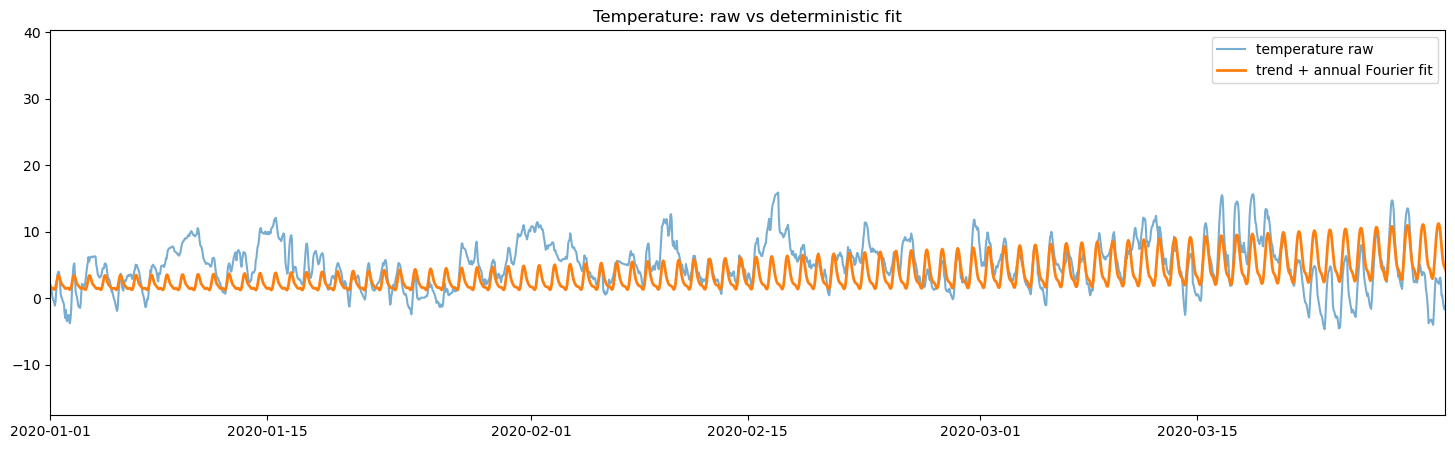

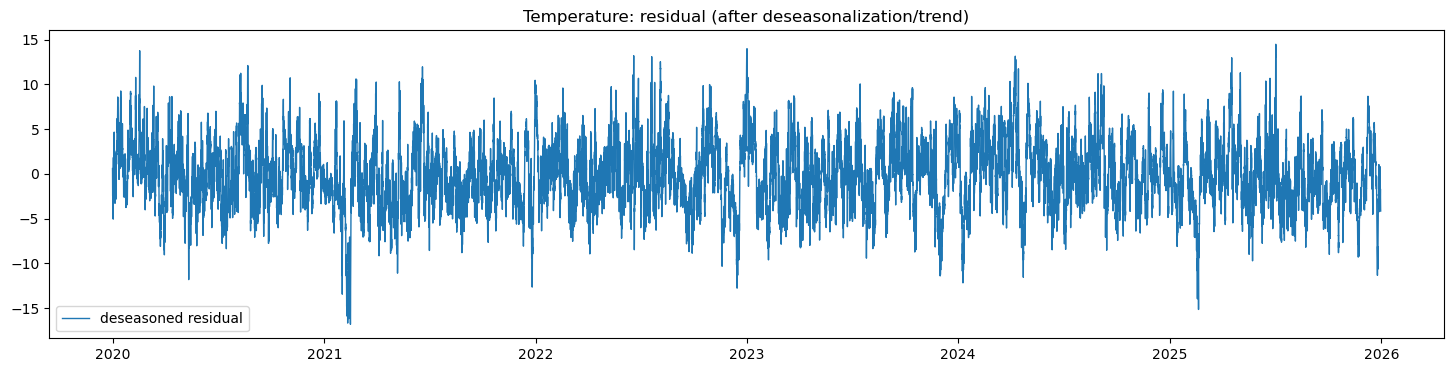

In [201]:
import matplotlib.pyplot as plt

plt.figure(figsize=(18,5))
plt.plot(temp.index, temp.values, alpha=0.6, label="temperature raw")
plt.plot(temp.index, temp_fit, linewidth=2, label="trend + annual Fourier fit")
plt.xlim(temp.index[0], temp.index[24*30*3])  
plt.legend()
plt.title("Temperature: raw vs deterministic fit")
plt.show()

plt.figure(figsize=(18,4))
plt.plot(temp_resid.index, temp_resid.values, linewidth=1, label="deseasoned residual")
plt.legend()
plt.title("Temperature: residual (after deseasonalization/trend)")
plt.show()


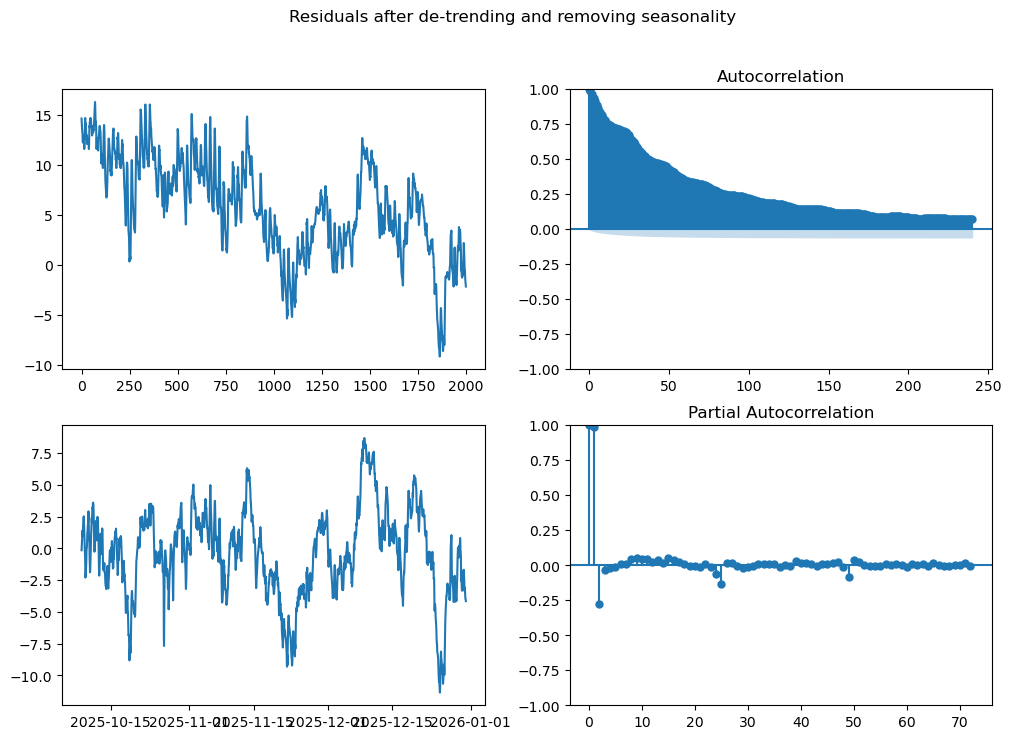

In [202]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.ar_model import AutoReg, ar_select_order, AutoRegResults

fig, axs = plt.subplots(2,2, figsize=(12,8))
fig.suptitle('Residuals after de-trending and removing seasonality')
axs[0,0].plot(temp.values[-2000:]    )
axs[1,0].plot(temp_resid[-2000:])
plot_acf(temp_resid, lags=10*24, ax=axs[0,1])
plot_pacf(temp_resid, lags=3*24, ax=axs[1,1])
plt.show()

FIT WITH CARMA/OU

95699.48574665177
95743.83658250149


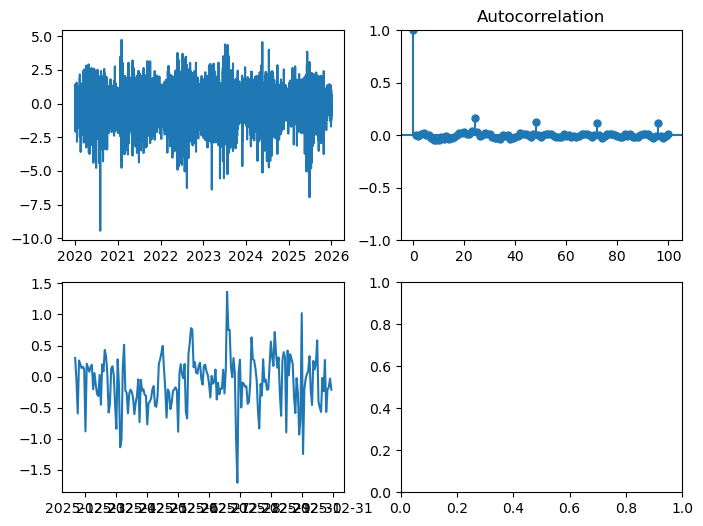

In [20]:
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA

model1 = ARIMA(temp_resid, order=(3, 0, 0))

results1 = model1.fit()

aic1 = results1.aic
bic1= results1.bic
print(aic1)
print(bic1)

res = results1.resid
fig, axs = plt.subplots(2,2, figsize=(8,6))
axs[0,0].plot(res)
axs[1,0].plot(res[-200:])
plot_acf(res, lags=10*10, ax=axs[0,1])
#plot_pacf(res, lags=20, ax=axs[1,1])
plt.show()

DESEASONALISE PRICES

FIRST METHOD: FOURIER SERIES+DUMMIES

In [9]:
import numpy as np
import pandas as pd

# Period params
P_day = 24
P_week= 24*7
P_month = 24*30.44
P_year = 365.25 * 24

# harmoniocs
K_day = 10
K_week= 6
K_month = 6
K_year = 6

price = prices_df["price_eur_mwh"].copy().sort_index().asfreq("h").interpolate(method="linear")

def filter_price(price):
    price_min = price.quantile(0.001)
    price_max = price.quantile(0.999)
    # .clip replaces values below price_min with price_min, and values above price_max with price_max
    return price.clip(lower=price_min, upper=price_max)


pricef=filter_price(price)

xp = ((pricef.index - pricef.index[0]) / pd.Timedelta(hours=1)).to_numpy(dtype=float)

def fourier_block(x, period, K):
    omega = 2*np.pi/period
    cols = []
    for k in range(1, K+1):
        cols.append(np.cos(k*omega*x))
        cols.append(np.sin(k*omega*x))
    return np.column_stack(cols)

hour_dummies = pd.get_dummies(pricef.index.hour, prefix='hour', drop_first=True).astype(float).values
day_dummies = pd.get_dummies(pricef.index.dayofweek, prefix='day', drop_first=True).astype(float).values
week_dummies = pd.get_dummies(pricef.index.isocalendar().week, prefix='week', drop_first=True).astype(float).values
month_dummies = pd.get_dummies(pricef.index.month, prefix='month', drop_first=True).astype(float).values

# Blocs de base

def get_interaction(b1, b2):
    inter = []
    for i in range(b1.shape[1]):
        for j in range(b2.shape[1]):
            inter.append(b1[:, i] * b2[:, j])
    return np.column_stack(inter)

X_intercept_trendp = [np.ones_like(xp), xp]
block_dayp = fourier_block(xp, P_day, K_day)
block_weekp= fourier_block(xp, P_week, K_week) 
block_monthp= fourier_block(xp, P_month, K_month)    
block_yearp = fourier_block(xp, P_year, K_year) 
inter_day_weekp = get_interaction(block_dayp, block_weekp)
inter_day_monthp = get_interaction(block_dayp, block_monthp)
inter_day_yearp = get_interaction(block_dayp, block_yearp)
inter_week_monthp = get_interaction(block_weekp, block_monthp)
inter_week_yearp = get_interaction(block_weekp, block_yearp)
inter_month_yearp = get_interaction(block_monthp, block_yearp)


Xp = np.column_stack(X_intercept_trendp + [
    block_dayp, 
    block_weekp, 
    block_monthp, 
    block_yearp,
    hour_dummies, 
    day_dummies,
    week_dummies,
    month_dummies,
    inter_day_weekp,
    inter_day_monthp,
    inter_day_yearp,
    inter_week_monthp,
    inter_week_yearp,
    inter_month_yearp,
])

# OLS
betap, *_ = np.linalg.lstsq(Xp, pricef.values, rcond=None)

# Fit et Résidus
price_fit = Xp @ betap
price_resid = pd.Series(pricef.values - price_fit, index=pricef.index, name="price_deseasoned")


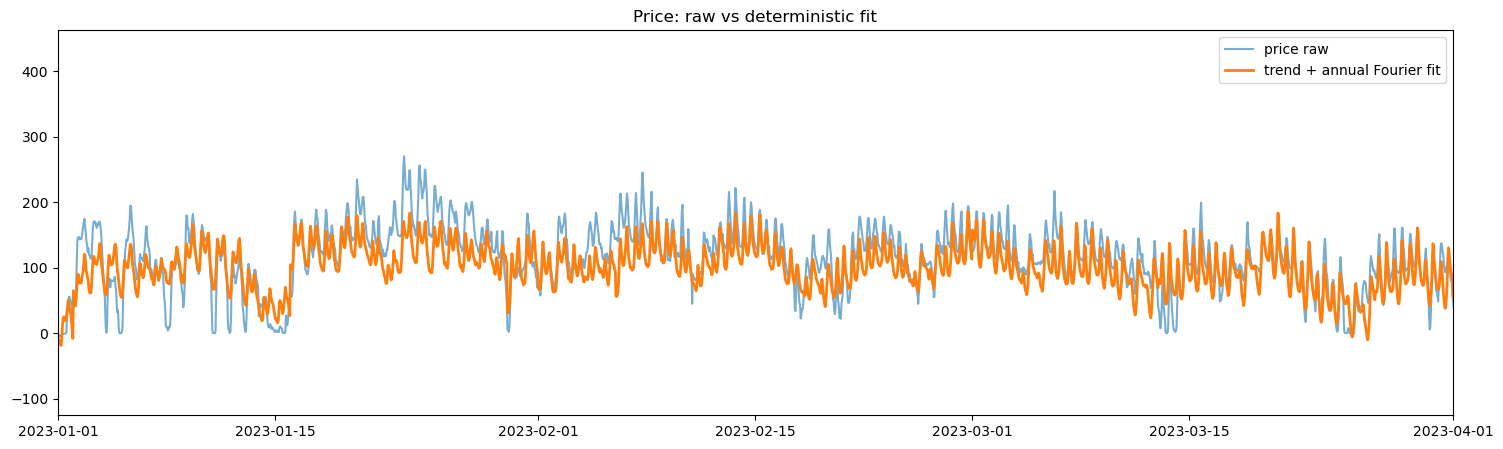

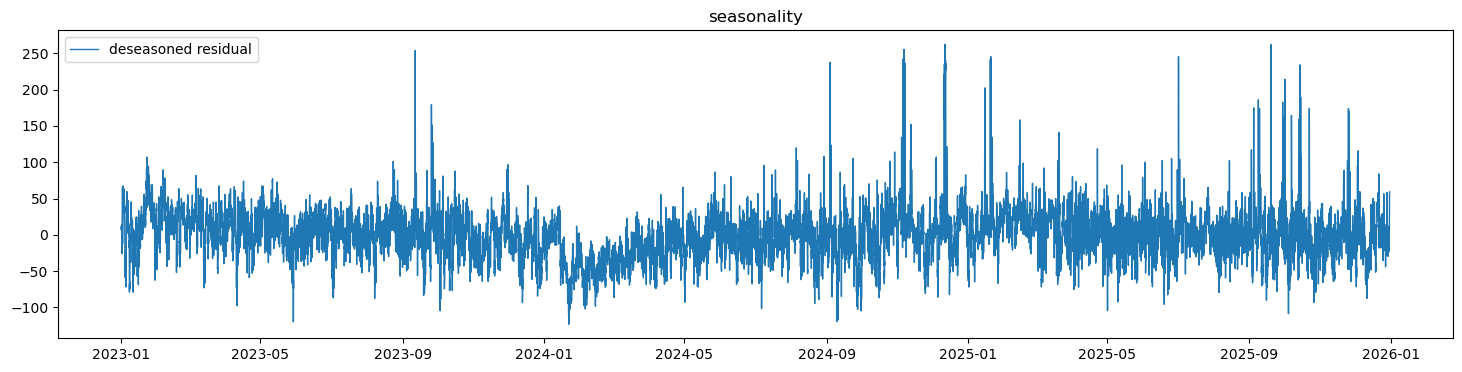

In [ ]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.ar_model import AutoReg, ar_select_order, AutoRegResults

plt.figure(figsize=(18,5))
plt.plot(price.index, pricef.values, alpha=0.6, label="price raw")
plt.plot(price.index, price_fit, linewidth=2, label="trend + annual Fourier fit")
plt.legend()
plt.xlim(price.index[0], price.index[24*30*3])
plt.title("Price: raw vs deterministic fit")
plt.show()

plt.figure(figsize=(18,4))
plt.plot(price_resid.index, price_resid.values, linewidth=1, label="deseasoned residual")
plt.legend()
plt.title("residuals")
plt.show()




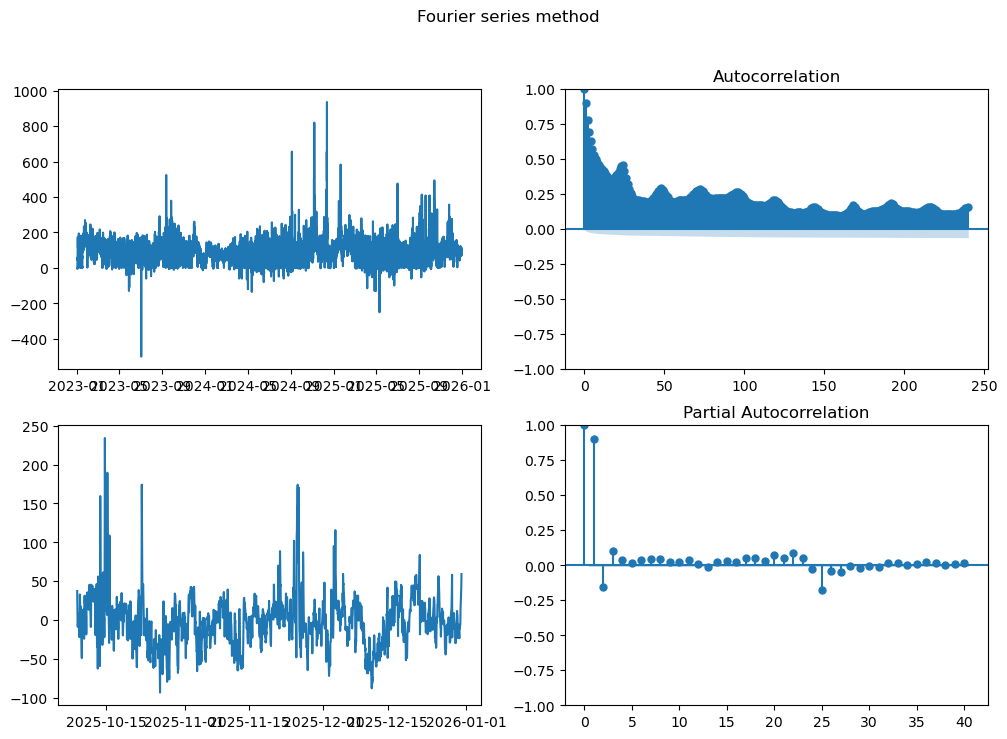

In [173]:
fig, axs = plt.subplots(2,2, figsize=(12,8))
fig.suptitle('Fourier series method')
axs[0,0].plot(price)
axs[1,0].plot(price_resid[-2000:])
plot_acf(price_resid, lags=24*10, ax=axs[0,1])
plot_pacf(price_resid, lags=40, ax=axs[1,1])
plt.show()

C:\Users\gabri\AppData\Local\Temp\ipykernel_18004\611163318.py:1: FutureWarning: old_names will be removed after the 0.14 release. You should stop setting this parameter and use the new names.
  modelp = AutoReg(price_resid, lags=3, old_names=True,trend='n')


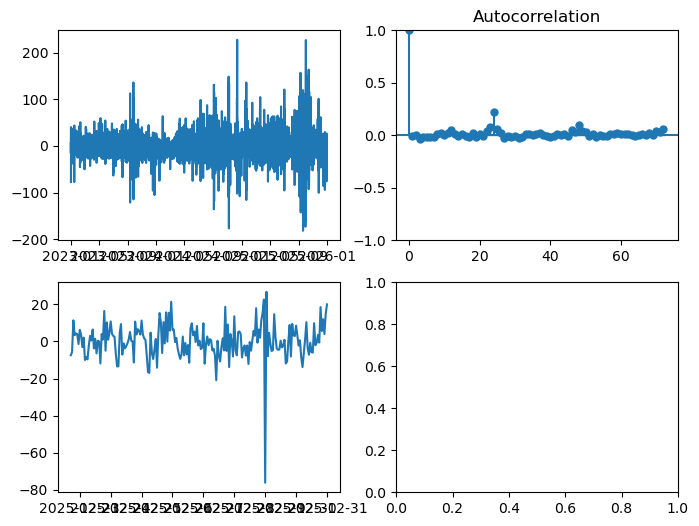

In [25]:
modelp = AutoReg(price_resid, lags=3, old_names=True,trend='n')
model_fit  = modelp.fit()
coef = model_fit.params
res = model_fit.resid
fig, axs = plt.subplots(2,2, figsize=(8,6))
axs[0,0].plot(res)
axs[1,0].plot(res[-200:])
plot_acf(res, lags=24*3, ax=axs[0,1])
#plot_pacf(res, lags=20, ax=axs[1,1])
plt.show()

SECOND METHOD: PARASCHIV (Fday*Fyear) WITH DUMMIES

Fday: daily seasonality

In [10]:
import numpy as np
import pandas as pd

day_mean = pricef.resample("D").mean()

day_mean_per_hour = day_mean.reindex(pricef.index.floor("D")).to_numpy(dtype=float)

f2d = (pricef.to_numpy(dtype=float) / day_mean_per_hour)

In [11]:
idx = pricef.index

dow = idx.dayofweek   
month = idx.month

profile_class = np.zeros(len(idx), dtype=int)

for i in range(len(idx)):

    m = month[i]
    d = dow[i]

    #weekdays (Mon-Fri)
    
    if d <= 4:
        profile_class[i] = m

    #saturady
    elif d == 5:

        if m in [1, 2, 12]:
            profile_class[i] = 13
        elif m in [3, 4, 5]:
            profile_class[i] = 14
        elif m in [6, 7, 8]:
            profile_class[i] = 15
        else:  # Sep-Oct-Nov
            profile_class[i] = 16

    #sunday
    elif d == 6:

        if m in [1, 2, 12]:
            profile_class[i] = 17
        elif m in [3, 4, 5]:
            profile_class[i] = 18
        elif m in [6, 7, 8]:
            profile_class[i] = 19
        else:  # Sep-Oct-Nov
            profile_class[i] = 20


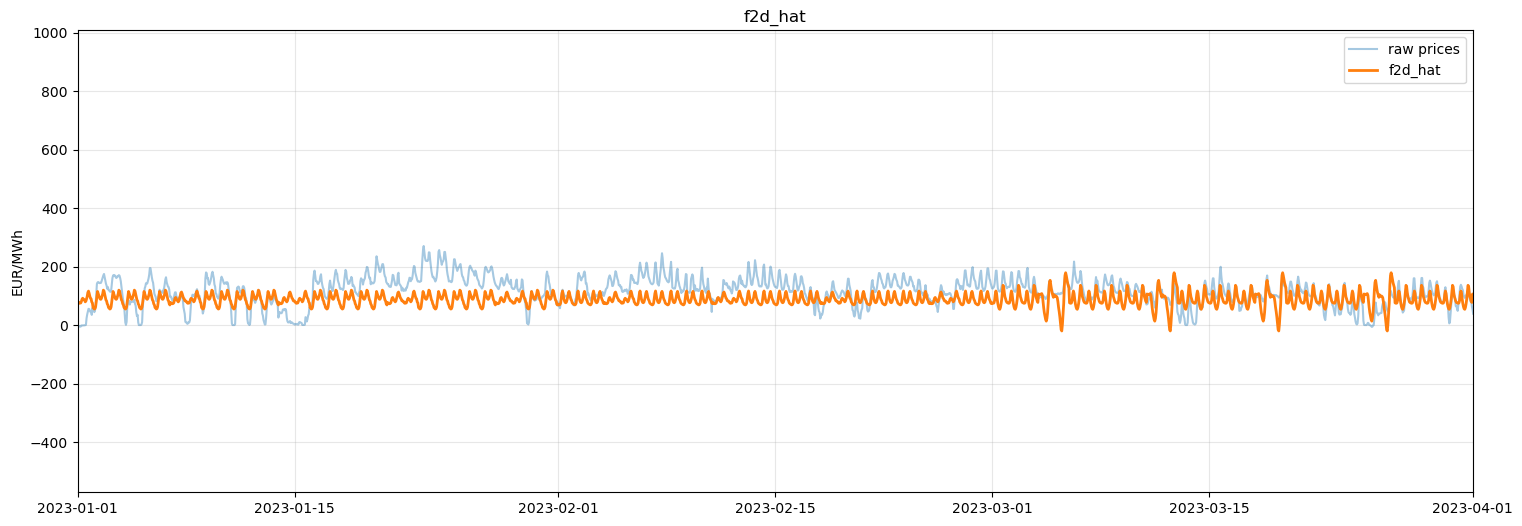

In [13]:
import matplotlib.pyplot as plt
hour_dummies = pd.get_dummies(idx.hour, drop_first=True).astype(float)
X = np.column_stack([np.ones(len(idx)), hour_dummies.to_numpy()])

f2d_hat = np.zeros(len(idx), dtype=float)
class_ids = np.unique(profile_class)

for class_id in class_ids:
    mask = (profile_class == class_id)
    X_class = X[mask]
    price_class = price[mask].to_numpy()
    
    coeffs, *_ = np.linalg.lstsq(X_class, price_class, rcond=None)
    predicted_prices = X_class @ coeffs
    
    mean_of_class_shape = np.mean(predicted_prices)
    if mean_of_class_shape != 0:
        f2d_hat[mask] = predicted_prices / mean_of_class_shape
    else:
        f2d_hat[mask] = 1.0

averageprice=price.mean()

plt.figure(figsize=(18,6))
plt.plot(idx, price.values, alpha=0.4, label="raw prices", color='tab:blue')
plt.plot(idx, averageprice*f2d_hat, label="f2d_hat", color='tab:orange', linewidth=2)

"""start_zoom = "2023-03-01"
end_zoom = "2023-04-15"
plt.xlim(pd.Timestamp(start_zoom), pd.Timestamp(end_zoom))"""

plt.title("f2d_hat")
plt.ylabel("EUR/MWh")
plt.xlim(price.index[0], price.index[24*30*3])
plt.legend()
plt.grid(alpha=0.3)
plt.show()


Fyear: yearly seasonality

In [14]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

S_day = price.resample("D").mean()

yearly_mean = S_day.groupby(S_day.index.year).transform("mean")
y = S_day / yearly_mean 

C:\Users\gabri\AppData\Local\Temp\ipykernel_17172\1455118231.py:9: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  combined_base = pd.concat([S_day, temp_day], axis=1).dropna()


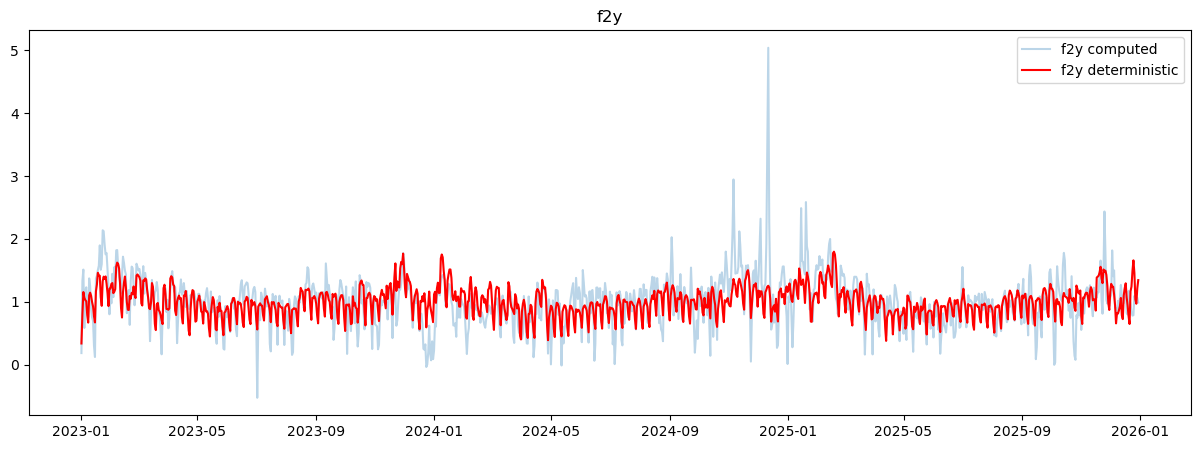

In [18]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

S_day = price.resample("D").mean()
temp_day = temp.resample("D").mean()

combined_base = pd.concat([S_day, temp_day], axis=1).dropna()
S_day = combined_base.iloc[:, 0]
temp_day = combined_base.iloc[:, 1]

#compute f2y target: ratio of daily price to its yearly mean
yearly_mean = S_day.groupby(S_day.index.year).transform("mean")
y = S_day / yearly_mean

X = pd.DataFrame(index=S_day.index)

#daily dummies
for d in range(6):
    day_labels = ['Lun', 'Mar', 'Mer', 'Jeu', 'Ven', 'Sam']
    X[day_labels[d]] = (X.index.dayofweek == d).astype(int)

#monthly dummies
for m in range(2, 13):
    if m != 8:  
        X[f'Mois_{m}'] = (X.index.month == m).astype(int)

#august split
X['Aout_Deb'] = ((X.index.month == 8) & (X.index.day <= 15)).astype(int)
X['Aout_Fin'] = ((X.index.month == 8) & (X.index.day > 15)).astype(int)

#meteorological variables
X['Chauffage_HDD'] = (15 - temp_day).clip(lower=0) 
X['Clim_CDD'] = (temp_day - 15).clip(lower=0) 

#constant(Alpha_0) 
X = sm.add_constant(X)

model_f2y = sm.OLS(y, X).fit()
f2y_d_hat = model_f2y.fittedvalues 

plt.figure(figsize=(15, 5))
plt.plot(y.index, y, label="f2y computed", alpha=0.3)
plt.plot(f2y_d_hat.index, f2y_d_hat, label="f2y deterministic", color='red')
plt.title("f2y")
plt.legend()
plt.show()

In [208]:
#turn daily f2y into hourly f2y
f2y_t_hat = f2y_d_hat.reindex(price.index.floor("D")).to_numpy()
f2y_t_hat = pd.Series(f2y_t_hat, index=price.index, name="f2y_t_hat")

In [209]:
#compute seasonality  s=f2y*f2d*average price
sw_t = f2y_t_hat * f2d_hat

yearly_avg = np.mean(pricef.values)
price_fit_paraschiv = sw_t * yearly_avg

residualparaschiv = residualparaschiv.ffill()

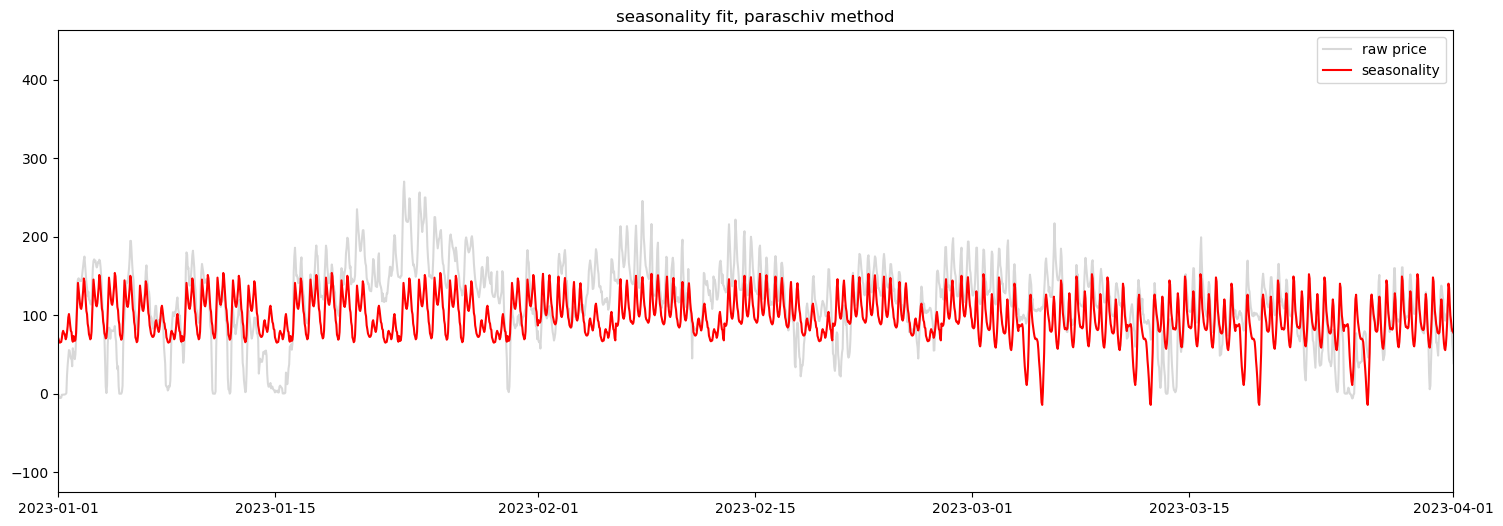

In [210]:
plt.figure(figsize=(18, 6))
plt.plot(price.index, pricef, alpha=0.3, label="raw price", color='gray')

plt.plot(price.index, price_fit_paraschiv, label="seasonality", color='red', linewidth=1.5)

plt.xlim(price.index[0], price.index[24*30*3]) 
plt.title("seasonality fit, paraschiv method")
plt.legend()
plt.show()

(-200.0, 200.0)

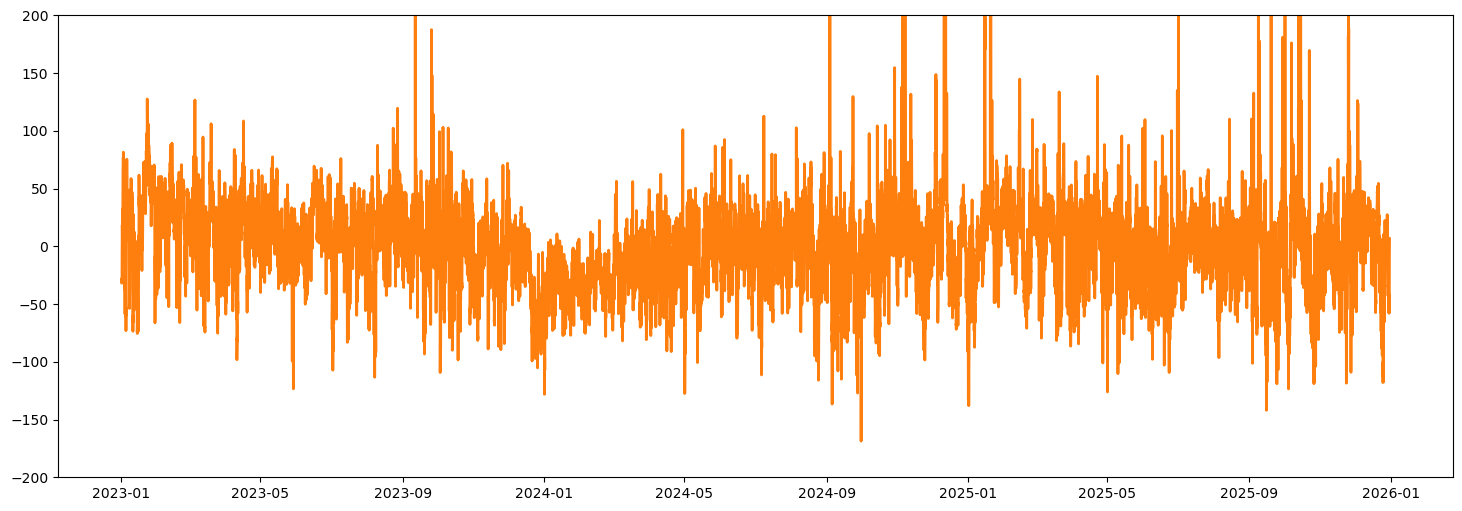

In [211]:
plt.figure(figsize=(18,6))
plt.plot(idx, residualparaschiv, color='tab:orange', linewidth=2)
plt.ylim(-200, 200)


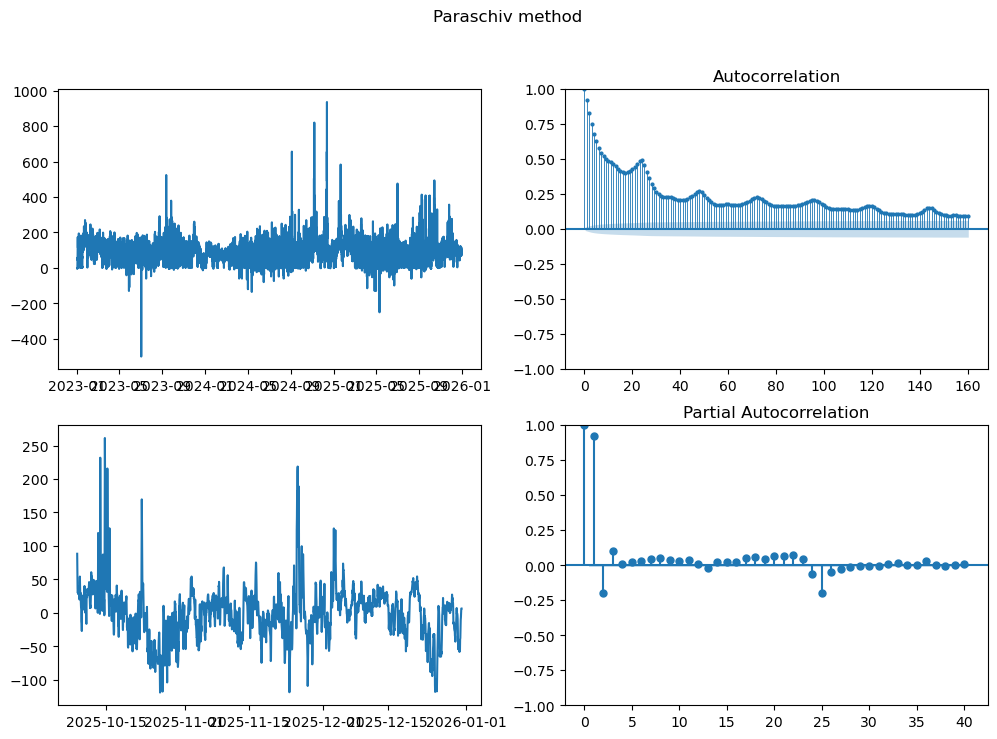

In [212]:
fig, axs = plt.subplots(2,2, figsize=(12,8))
fig.suptitle('Paraschiv method')
axs[0,0].plot(price)
axs[1,0].plot(residualparaschiv[-2000:])
plot_acf(residualparaschiv, lags=160, ax=axs[0,1],vlines_kwargs={"linewidth":0.6}, markersize=2)
plot_pacf(residualparaschiv, lags=40, ax=axs[1,1])
plt.show()

PRICE VOLATILITY 

In [ ]:
import numpy as np
import pandas as pd

# time periods
P_day = 24
P_week= 24*7
P_month = 24*30.44
P_year = 365.25 * 24

# harmonics
K_day = 2
K_week= 2
K_month = 2
K_year = 2

volp=abs(residualparaschiv)
xp = ((price.index - price.index[0]) / pd.Timedelta(hours=1)).to_numpy(dtype=float)

def fourier_block(x, period, K):
    omega = 2*np.pi/period
    cols = []
    for k in range(1, K+1):
        cols.append(np.cos(k*omega*x))
        cols.append(np.sin(k*omega*x))
    return np.column_stack(cols)

def get_interaction(b1, b2):
    inter = []
    for i in range(b1.shape[1]):
        for j in range(b2.shape[1]):
            inter.append(b1[:, i] * b2[:, j])
    return np.column_stack(inter)

X_intercept_trendvolp = [np.ones_like(xp), xp]
block_dayvolp = fourier_block(xp, P_day, K_day)
block_weekvolp= fourier_block(xp, P_week, K_week) 
block_monthvolp= fourier_block(xp, P_month, K_month)    
block_yearvolp = fourier_block(xp, P_year, K_year) 
inter_day_weekvolp = get_interaction(block_dayvolp, block_weekvolp)
inter_day_monthvolp = get_interaction(block_dayvolp, block_monthvolp)
inter_day_yearvolp = get_interaction(block_dayvolp, block_yearvolp)
inter_week_monthvolp = get_interaction(block_weekvolp, block_monthvolp)
inter_week_yearvolp = get_interaction(block_weekvolp, block_yearvolp)
inter_month_yearvolp = get_interaction(block_monthvolp, block_yearvolp)


Xvolp = np.column_stack(X_intercept_trendvolp + [
    block_dayvolp, 
    block_weekvolp, 
    block_monthvolp, 
    block_yearvolp,
    inter_day_weekvolp,
    inter_day_monthvolp,
    inter_day_yearvolp,
    inter_week_monthvolp,
    inter_week_yearvolp,
    inter_month_yearvolp
])

# OLS
betavolp, *_ = np.linalg.lstsq(Xvolp, volp.values, rcond=None)

volp_fit = Xvolp @ betavolp

#Volatiity must be>0
volp_fit = abs(volp_fit)

final_residp = pd.Series(
    residualparaschiv / volp_fit, 
    index=price.index, 
    name="standardized_residuals"
)


(-10.0, 10.0)

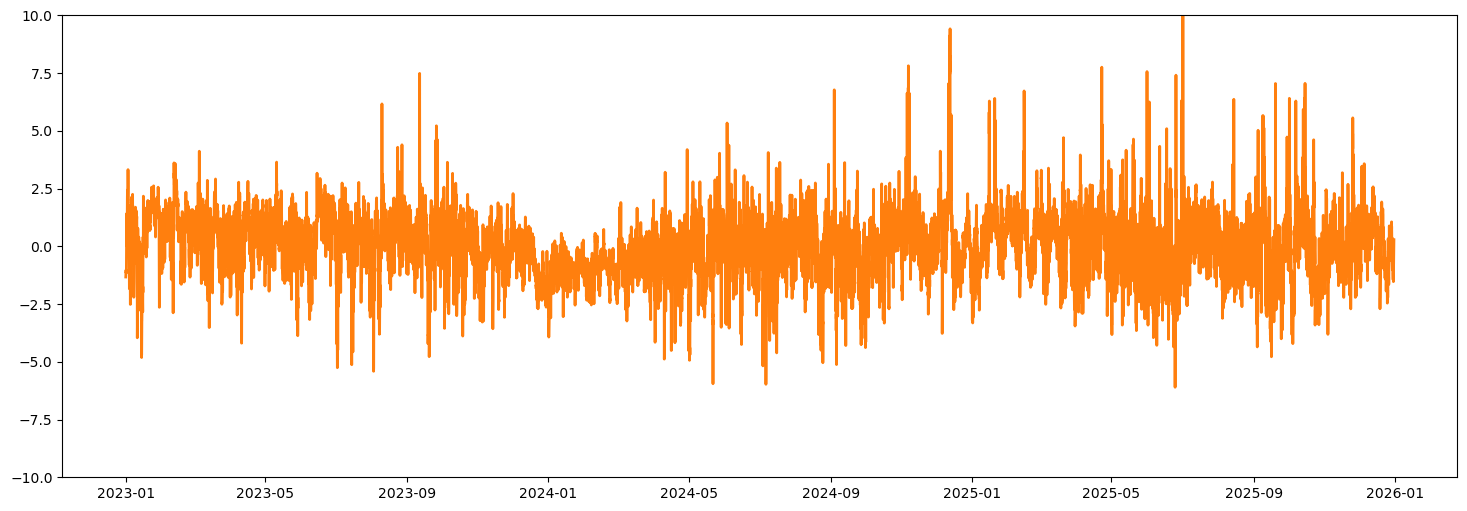

In [164]:
plt.figure(figsize=(18,6))
plt.plot(idx, final_residp, color='tab:orange', linewidth=2)
plt.ylim(-10,10)


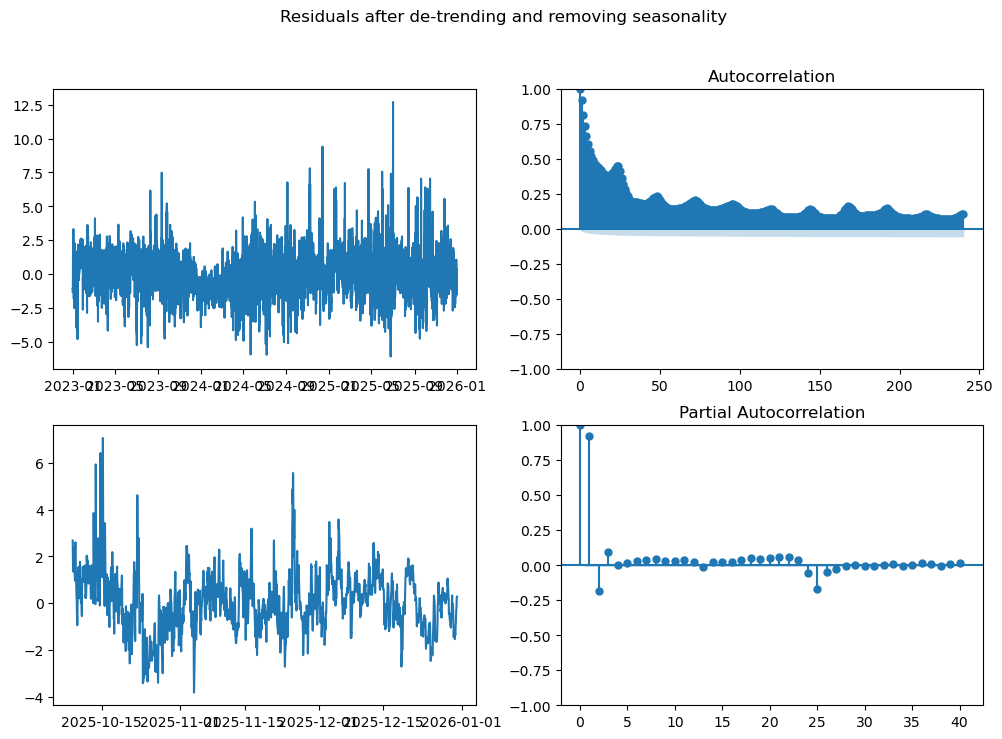

In [165]:
fig, axs = plt.subplots(2,2, figsize=(12,8))
fig.suptitle('Residuals after de-trending and removing seasonality')
axs[0,0].plot(final_residp)
axs[1,0].plot(final_residp[-2000:])
plot_acf(final_residp, lags=24*10, ax=axs[0,1])
plot_pacf(final_residp, lags=40, ax=axs[1,1])
plt.show()